# 1. Датасет: Students Performance in Exams
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

### 1.2. 
- Проблемная область: образование, сет содержит информацию о результатах студетов на экзаменах по математике, чтению и письму, а также характеристики типа: пол, расы уровень образования родителейя. обед, курс подготовки.
- Цель — оценить, как факторы влияют на результат сдачи экзамена.
### 1.3. 
- Объекты наблюдения:студенты; 
- Атрибуты объектов:gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score. (пол, -раса/этническая принадлежность, уровень образования родителей, обед, курс подготовки к тестированию, оценка по математике, оценка по чтению, оценка по письму) 
- Связи между объектами: получается связей нет, студенты независимы.
### 1.4. 
- Бизнес-цели: оптимизировать программы образования, основываясь на факторах успеваемости; 
- Эффект для бизнеса: повысить результаты тестирований, улучшить образование. 
### 1.5. 
- Примеры тех.проекта: предсказать балл по математике студента на основе признаков; 
- Вход: атрибуты: reading score, writing score, gender, race/ethnicity, parental level of education, lunch, test preparation course.
- Целевой признак: math score.

### 1.6 Проблемы выбранных наборов данных. Зашумленность, смещение, актуальность, выбросы, просачивание данных

In [28]:
import pandas as pd
students = pd.read_csv("data//StudentsPerformance.csv", sep=",")
print('количество колонок: ' + str(students.columns.size))  
print('колонки: ' + ', '.join(students.columns))

количество колонок: 8
колонки: gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score


- Зашумленность: Возможны ошибки ввода (например, некорректные категории или опечатки), общим взглядом — такого нет в сете.
- Смещение: Данные собраны по ограниченной выборке студентов из США, не отражают мировую картину.
- Актуальность: Данные достаточно старые (2018 год), могут быть уже неактуальными.
- Выбросы: Очень низкие или высокие баллы по предметам (0 или 100) могут быть выбросами, проверим:

math score: выбросов — 8
reading score: выбросов — 6
writing score: выбросов — 5


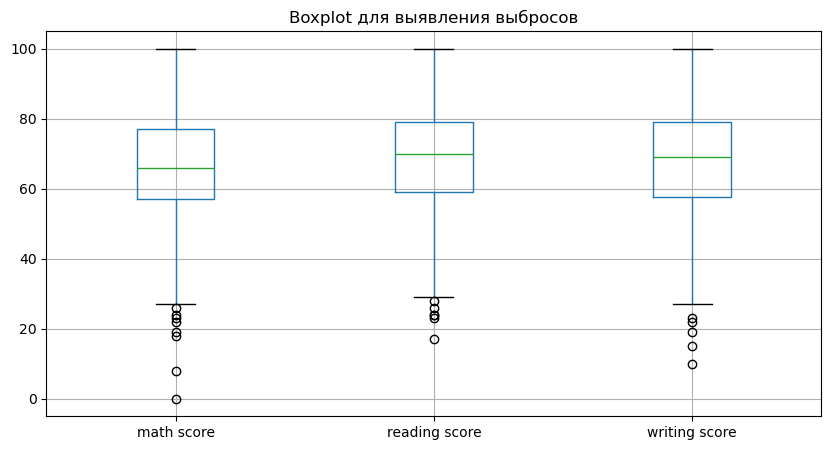

In [29]:
numeric_cols = students.select_dtypes(include=['int64', 'float64']).columns # проверяем только столбцы с значениями инт и флот

# Рассчёт границ выбросов по каждому числовому столбцу
for col in numeric_cols:
    Q1 = students[col].quantile(0.25)
    Q3 = students[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR # нижняя граница
    upper_bound = Q3 + 1.5 * IQR # верхняя граница
    outliers = students[(students[col] < lower_bound) | (students[col] > upper_bound)]  # значения, выходящие из диапазона границ
    print(f"{col}: выбросов — {len(outliers)}")


import matplotlib.pyplot as plt

students[numeric_cols].boxplot(figsize=(10,5))
plt.title("Boxplot для выявления выбросов")
plt.show()


Вывод: Выбросов очень мало, все нормально! Тем более они все ниже основной части диаграммы, может наши студенты устали к экзаменам(

- Просачивание данных: Если, например, при построении модели использовать значение оценок по другим тестам как входной признак для предсказания оставшегося из них. Знаем оценки по reading score, writing score -> можем получить math score

math score       1.000000
reading score    0.817580
writing score    0.802642
Name: math score, dtype: float64
-------------------


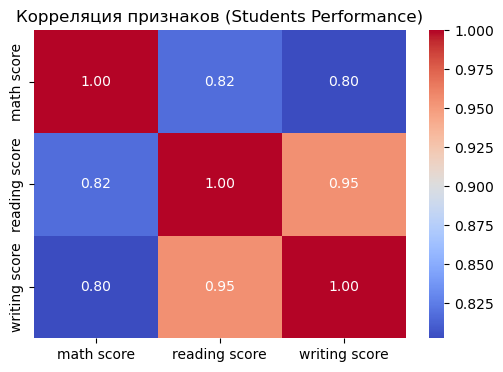

In [30]:
# Пример: проверим корреляцию целевого признака (math score) с признаками reading score, writing score
target = 'math score'  
corr = students.corr(numeric_only=True)[target].sort_values(ascending=False)
print(corr)

print("-------------------")

import seaborn as sns
# Вычисляем корреляцию только между числовыми признаками
corr = students.corr(numeric_only=True)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Корреляция признаков (Students Performance)")
plt.show()

Вывод: студенты, которые хорошо справляются в математике, в среднем также хорошо справляются с чтением и письмом.

### 1.7. Решение проблем

- Зашумленность: можно проверить значения на уникальность, исправление опечаток.
- Смещение: Добавить выборки из других регионов, если возможно.
- Актуальность: Использовать обновлённые данные.
- Выбросы: Использовать IQR (межквартильный размах) для фильтрации экстремальных значений.
- Просачивание: Исключить зависимые переменные из входных данных.

### 1.8. Оценка качества данных

- Информативность: Высокая. Много признаков, влияющих на результат.
- Степень покрытия: Средняя. Данные по ограниченной группе учеников.
- Соответствие реальным данным: Средняя.Могут не отражать все социальные факторы.
- Согласованность меток: Хорошая. Баллы представлены в числовом формате без явных ошибок.

### 1.9 Разбиение набора данных на выборки

In [51]:
# разделим на обучающую(70%), контрольную(15%) и тестовую (15%) выборки.

from sklearn.model_selection import train_test_split

# Преобразуем категориальные признаки в числовые для удобства разбиения
students_encoded = pd.get_dummies(students, drop_first=True)

# Выбираем целевой признак (math score)
target = 'math score'
X = students_encoded.drop(columns=[target])
y = students_encoded[target]

# 1: train (70%) и temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, shuffle=True)

# 2: control (15%) и test (15%)
X_control, X_test, y_control, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

# Проверяем размеры
print(f"Размер обучающей выборки: {X_train.shape[0]} ({round(X_train.shape[0]/students.shape[0]*100,1)}%)")
print(f"Размер контрольной выборки: {X_control.shape[0]} ({round(X_control.shape[0]/students.shape[0]*100,1)}%)")
print(f"Размер тестовой выборки: {X_test.shape[0]} ({round(X_test.shape[0]/students.shape[0]*100,1)}%)")


Размер обучающей выборки: 700 (70.0%)
Размер контрольной выборки: 150 (15.0%)
Размер тестовой выборки: 150 (15.0%)


### 1.10 Пропущенные данные

In [32]:
# Всего сколько пустых значений у признаков
print(students.isnull().sum())

print()

# Проверка, что у признаков есть пустые значения
print(students.isnull().any())

print()

# Процент пустых значений признаков
for i in students.columns:
    null_rate = students[i].isnull().sum() / len(students) * 100
    if null_rate > 0:
        print(f"{i} процент пустых значений: %{null_rate:.2f}")
        
print("Количество записей:", len(students))

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

gender                         False
race/ethnicity                 False
parental level of education    False
lunch                          False
test preparation course        False
math score                     False
reading score                  False
writing score                  False
dtype: bool

Количество записей: 1000


Вывод: пропущенных данных нет, поэтому с этой проблемой бороться не пришлось.

### 1.11 Оценка сбалансированности выборки

In [52]:
# Преобразуем категориальные признаки в числовые
df_encoded = pd.get_dummies(students, drop_first=True)

# Категоризируем math score
bins = [0, 60, 80, 100]
labels = ['Low', 'Medium', 'High']
df_encoded['math_level'] = pd.cut(students['math score'], bins=bins, labels=labels, include_lowest=True)

# Выводим количество записей в каждой категории
print("Количество записей по уровням успеваемости:")
print(df_encoded['math_level'].value_counts().sort_index())

Количество записей по уровням успеваемости:
math_level
Low       339
Medium    485
High      176
Name: count, dtype: int64


Классы low, medium, high распределены неравномерно, значит выборка несбалансированна. 

### 1.12 Приращение данных

In [53]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

# Oversampling
X_aug = X_train.copy()
y_aug = y_train.copy()

# Добавляем шум ±0.3% от значения
noise = np.random.normal(0, 0.003, size=len(y_train))
y_augmented = y_train * (1 + noise)

# Объединяем оригинальные и аугментированные данные
X_balanced = pd.concat([X_train, X_aug], axis=0)
y_balanced = pd.concat([y_train, pd.Series(y_augmented)], axis=0)

print(f"Размер до аугментации: {len(y_train)}")
print(f"Размер после Oversampling: {len(y_balanced)}")

# Undersampling
undersample_frac = 0.7
X_under = X_train.sample(frac=undersample_frac, random_state=42)
y_under = y_train.loc[X_under.index]

print(f"Размер после Undersampling: {len(y_under)}")


Размер до аугментации: 700
Размер после Oversampling: 1400
Размер после Undersampling: 490


# 2. Датасет: Starbucks Stock Price Dataset
https://www.kaggle.com/datasets/mayankanand2701/starbucks-stock-price-dataset

### 2.2. 
- Проблемная область: финансы, сет содержит исторические котировки акций Starbucks за последние 25 лет.
- Цель — прогнозирование цен на акции и анализ рыночной активности.
### 2.3. 
- Объекты наблюдения: акции; Атрибуты объектов: Date, Open, High, Low, Close, Adj Close, Volume. (Пояснения по столбцам: Дата — Дата торгового дня, Открытие — Начальная цена акций Starbucks в указанный день, Максимум — Самая высокая цена акций Starbucks в течение торгового дня, Минимум — Самая низкая цена акций Starbucks в течение торгового дня, Закрытие — Цена закрытия акций Starbucks в указанный день, Корректировка закрытия — Скорректированная цена закрытия акций Starbucks, Объем — Объем торгов акциями Starbucks за указанный день) 
- Связи между объектами: данные упорядочены по времени
### 2.4. 
- Бизнес-цели: построение модели прогнозирования цен акций для алгоритмической торговли;
- Эффект для бизнеса: увеличить дшходность от портфеля инвестиций.
### 2.5. 
- Примеры тех.проекта: предсказание цены закрытия акций на следующий день.
- Вход: Date, Open, High, Low, Volume.
- Целевой признак: Close следующего дня.

### 2.6 Проблемы выбранных наборов данных. Зашумленность, смещение, актуальность, выбросы, просачивание данных

In [12]:
import pandas as pd
starbucks = pd.read_csv("data//StarbucksDataset.csv", sep=",")
print('количество колонок: ' + str(starbucks.columns.size))  
print('колонки: ' + ', '.join(starbucks.columns))

количество колонок: 7
колонки: Date, Open, High, Low, Close, Adj Close, Volume


- Зашумленность: Рыночные данные шумные, но тут влияние от экономики.
- Смещение: Нет смещения в структуре, но возможно неполное покрытие.
- Актуальность: Данные вполне актуальные, самая свежая дата ниже.

In [13]:
# Преобразование столбца 'Date' к формату datetime
starbucks['Date'] = pd.to_datetime(starbucks['Date'])

# Нахождение самой свежей даты
latest_date = starbucks['Date'].max()

print("Самая свежая дата:", latest_date)

Самая свежая дата: 2024-05-23 00:00:00


- Выбросы: Выбросов достаточно много, но тут работа с акциями, скачки которых происходят довольно часто. 
- Просачивание:

<Figure size 1000x600 with 0 Axes>

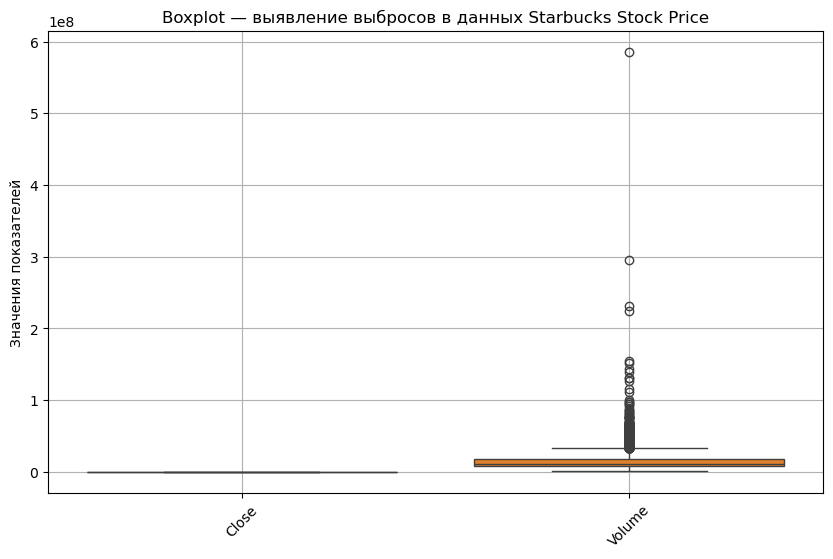

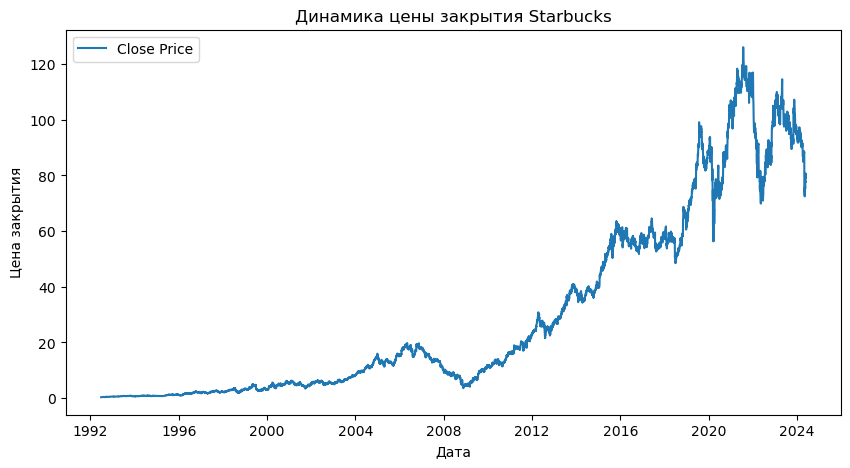

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = ['Close', 'Volume']

# Построим ящик с усами
plt.figure(figsize=(10,6))
sns.boxplot(data=starbucks[numeric_cols])
plt.title("Boxplot — выявление выбросов в данных Starbucks Stock Price")
plt.xticks(rotation=45)
plt.ylabel("Значения показателей")
plt.grid(True)
plt.show()

# Визуализация временной зависимости
plt.figure(figsize=(10,5))
plt.plot(starbucks['Date'], starbucks['Close'], label='Close Price')
plt.title("Динамика цены закрытия Starbucks")
plt.xlabel("Дата")
plt.ylabel("Цена закрытия")
plt.legend()
plt.show()

### 2.7. Решение проблем

- Зашумленность: Применение сглаживания (например, скользящего среднего).
- Смещение: Использовать полные временные ряды без пропусков..
- Актуальность: Данные уже свежие.
- Выбросы: Нормализация и фильтрация аномальных скачков.
- Просачивание: Следить, чтобы тренировочные данные включали только прошлое относительно целевого дня.

### 2.8. Оценка качества данных

- Информативность: Высокая. Есть все стандартные метрики для анализа акций(Date, Open, High, Low, Close, Volume).
- Степень покрытия: Высокая. Данные почти каждый день.
- Соответствие реальным данным: Высокое. Совпадает с историей фондового рынка. 
- Согласованность меток: Высокий. Строгий формат финансовых данных.

### 2.9 Разбиение набора данных на выборки

In [15]:
# Целевой признак
target = 'Close'

X = starbucks.drop(columns=['Close', 'Date'])
y = starbucks[target]

# Разделяем на train (70%), temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, shuffle=False)

# Делим temp на control и test по 15% каждая
X_control, X_test, y_control, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

print(f"Размер обучающей выборки: {len(X_train)} ({len(X_train)/len(starbucks)*100:.1f}%)")
print(f"Размер контрольной выборки: {len(X_control)} ({len(X_control)/len(starbucks)*100:.1f}%)")
print(f"Размер тестовой выборки: {len(X_test)} ({len(X_test)/len(starbucks)*100:.1f}%)")


Размер обучающей выборки: 5625 (70.0%)
Размер контрольной выборки: 1205 (15.0%)
Размер тестовой выборки: 1206 (15.0%)


### 2.10 Пропущенные данные

In [16]:
# Всего сколько пустых значений у признаков
print(starbucks.isnull().sum())

print()

# Проверка, что у признаков есть пустые значения
print(starbucks.isnull().any())

print()

# Процент пустых значений признаков
for i in starbucks.columns:
    null_rate = starbucks[i].isnull().sum() / len(starbucks) * 100
    if null_rate > 0:
        print(f"{i} процент пустых значений: %{null_rate:.2f}")
        
print("Количество записей:", len(starbucks))

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Date         False
Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool

Количество записей: 8036


Вывод: пропущенных данных нет, поэтому с этой проблемой бороться не пришлось.

### 2.11 Оценка сбалансированности выборки

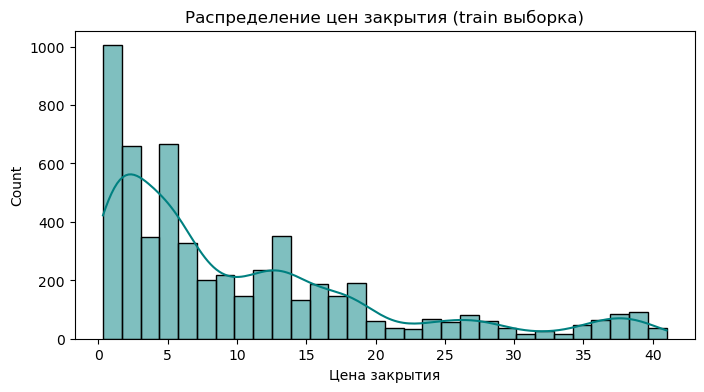

count    5625.000000
mean       10.201901
std        10.059906
min         0.335938
25%         2.414063
50%         6.039063
75%        14.515000
max        40.994999
Name: Close, dtype: float64


In [17]:
# Распределение цен в обучающей выборке
plt.figure(figsize=(8,4))
sns.histplot(y_train, kde=True, color='teal')
plt.title("Распределение цен закрытия (train выборка)")
plt.xlabel("Цена закрытия")
plt.show()

print(y_train.describe())


Данных вполне достаточно. Хорошо подойдет Undersampling.

### 2.12 Приращение данных

In [18]:
# Создаем синтетические точки — копии с небольшим шумом
X_aug = X_train.copy()
y_aug = y_train * (1 + np.random.normal(0, 0.005, size=len(y_train)))  # шум ±0.5%

# Объединяем
X_balanced = pd.concat([X_train, X_aug], axis=0)
y_balanced = pd.concat([y_train, pd.Series(y_aug)], axis=0)

print(f"Размер до oversampling: {len(y_train)}")
print(f"Размер после oversampling: {len(y_balanced)}")

# Undersampling.
# Берем случайные 70% записей
X_under = X_train.sample(frac=0.7, random_state=42)
y_under = y_train.loc[X_under.index]

print(f"Размер после undersampling: {len(y_under)}")

Размер до oversampling: 5625
Размер после oversampling: 11250
Размер после undersampling: 3937


# 3. Датасет: World Population
https://www.kaggle.com/datasets/muhammedtausif/world-population-by-countries

### 3.2. 
- Проблемная область: демография, прогнозирование роста населения, сет будет полезен для анализа динамики населения по странам и континентам, прогнозирования будущих изменений. Сейчас уже указан прогноз населения до 2050 с шагом в 5 лет, начиная с 2020 года.
### 3.3. 
- Объекты наблюдения: страны; 
- Атрибуты объектов: Year, Population, Yearly %, Yearly, Median, Fertility, Density (Год, Население, Годовой %, Годовой, Медиана, Рождаемость, Плотность) 
- Связи между объектами: зависимость численности населения от времени
### 3.4. 
- Бизнес-цели: Прогнозирование спроса на продукты, жильё, энергоресурсы.
- Эффект для бизнеса: эффективное долгосрочное планирование экономики
### 3.5. 
- Примеры тех.проекта: предсказать численность населения 
- Вход: Year, Fertility, Yearly 
- Признак: Population

### 3.6 Проблемы выбранных наборов данных. Зашумленность, смещение, актуальность, выбросы, просачивание данных

In [19]:
import pandas as pd
population = pd.read_csv("data//WorldPopulation.csv", sep=",", encoding='latin1')
print('количество колонок: ' + str(population.columns.size))  
print('колонки: ' + ', '.join(population.columns))

количество колонок: 7
колонки: Year, Population, Yearly %, Yearly, Median, Fertility, Density


Перед тем как работать с данными уберем лишнюю сторку, она содержит единицы измерения для колонки. 

In [20]:
print(population.iloc[0:1])
print('-----------------------')

population = population.drop(index=0)
print(population.iloc[0:3])

       Year Population Yearly %  Yearly Median Fertility  Density
0  (July 1)        NaN   Change  Change    Age      Rate  (P/Kmý)
-----------------------
   Year     Population Yearly %      Yearly Median Fertility Density
1  2020  7,794,798,739    1.10%  83,000,320     31      2.47      52
2  2025  8,184,437,460    0.98%  77,927,744     32      2.54      55
3  2030  8,548,487,400    0.87%  72,809,988     33      2.62      57


Тут видим ещё одну проблему: и проценты в ячейках, и много запятых. Избавимся от этого:

In [21]:
def clean_number(x):
    if pd.isna(x):
        return None
    x = str(x).replace(',', '').replace('%', '').replace('"', '').strip()
    try:
        return float(x)
    except ValueError:
        return None

# Применим очистку ко всем числовым колонкам, кроме 'Year'
for col in ['Population', 'Yearly %', 'Yearly', 'Median', 'Fertility', 'Density']:
    population[col] = population[col].apply(clean_number)

# Приведем к int некоторые столбцы
population['Year'] = population['Year'].astype(int)
population['Population'] = population['Population'].astype(int)
population['Yearly'] = population['Yearly'].astype(int)

# Проверим результат
print(population.dtypes)
print(population.iloc[0:3])

Year            int64
Population      int64
Yearly %      float64
Yearly          int64
Median        float64
Fertility     float64
Density       float64
dtype: object
   Year  Population  Yearly %    Yearly  Median  Fertility  Density
1  2020  7794798739      1.10  83000320    31.0       2.47     52.0
2  2025  8184437460      0.98  77927744    32.0       2.54     55.0
3  2030  8548487400      0.87  72809988    33.0       2.62     57.0


- Зашумленность: Минимальная, так как данные прогнозные, а не измеренные. По графикам вообще линейная зависимость.
- Смещение: Возможное — модель прогноза основана на исторических тенденциях, не учитывает войны, миграции, катастрофы.
- Актуальность: Высокая — прогноз до 2050 г., но может устареть при обновлении демографических моделей.
- Выбросы: Их нет.
- Просачивание данных: Нет, прогнозы независимы по годам и странам.

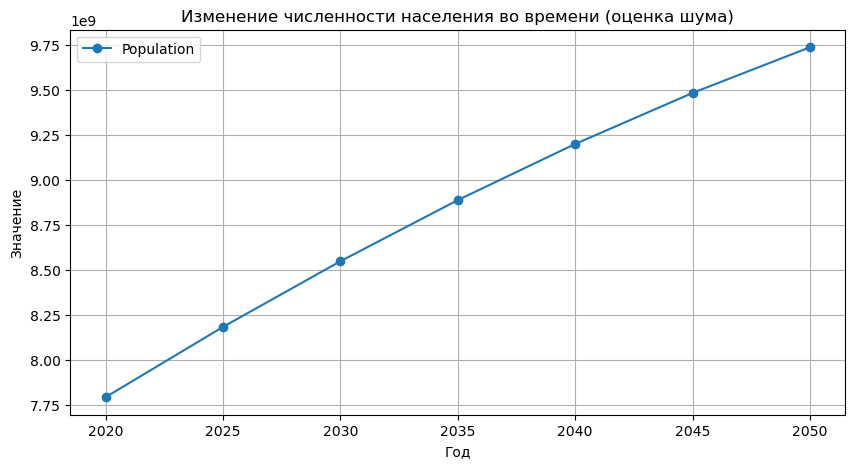

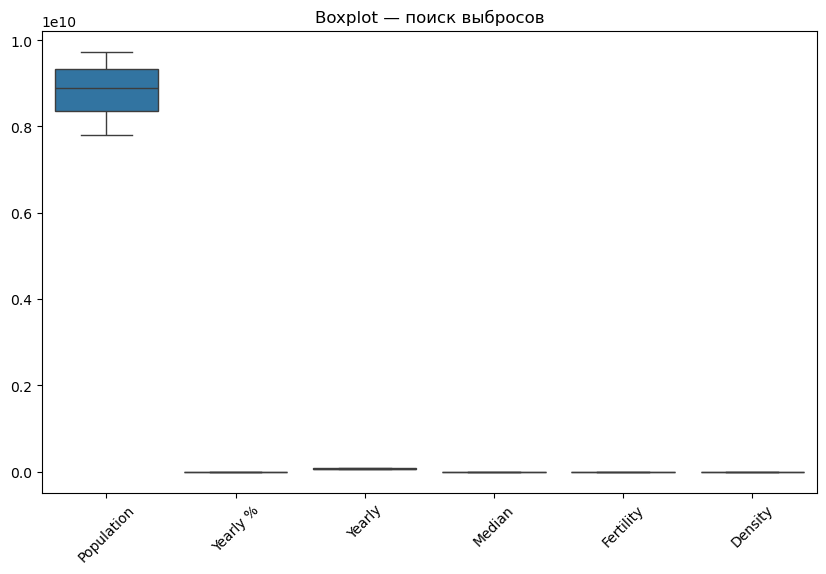

In [22]:
import seaborn as sns
import numpy as np
numeric_cols = ['Population', 'Yearly %', 'Yearly', 'Median', 'Fertility', 'Density']

# Шум
plt.figure(figsize=(10,5))
plt.plot(population['Year'], population['Population'], marker='o', label='Population')
plt.title("Изменение численности населения во времени (оценка шума)")
plt.xlabel("Год")
plt.ylabel("Значение")
plt.legend()
plt.grid(True)
plt.show()

# Boxplot для всех признаков
plt.figure(figsize=(10,6))
sns.boxplot(data=population[numeric_cols])
plt.title("Boxplot — поиск выбросов")
plt.xticks(rotation=45)
plt.show()

### 3.7 Решение проблем

- Зашумленность: Использовать альтернативные прогнозы (например, ООН).
- Смещение: —
- Актуальность: Это и так прогноз, поэтому можно регулярно обновлять прогноз при выходе новых данных.
- Выбросы: Тут нечего делать, нулевых или отрицательных значений нету.
- Просачивание: —

### 3.8 Оценка качества данных

- Информативность: Средняя. Позволяет строить прогнозы и аналитические модели.
- Степень покрытия: Высокая. Все страны и года (2020–2050).
- Соответствие реальным данным: Низкая. Так как большая часть значений это прогнозы.
- Согласованность меток: Высокая. Формат таблицы стандартизирован.

### 3.9 Разбиение набора данных на выборки

Очень мало данных, но мы попытаемся..

Размер обучающей выборки: 4 (57.1%)
Размер контрольной выборки: 1 (14.3%)
Размер тестовой выборки: 2 (28.6%)


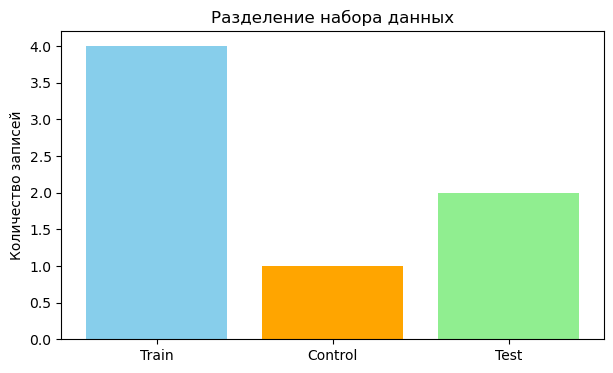

In [24]:
# разделим на обучающую(70%), контрольную(15%) и тестовую (15%) выборки.
# Целевой признак: Population
X = population.drop(columns=['Population'])
y = population['Population']

# Шаг 1: train (70%) и temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, shuffle=False)

# Шаг 2: control (15%) и test (15%)
X_control, X_test, y_control, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

print(f"Размер обучающей выборки: {len(X_train)} ({len(X_train)/len(population)*100:.1f}%)")
print(f"Размер контрольной выборки: {len(X_control)} ({len(X_control)/len(population)*100:.1f}%)")
print(f"Размер тестовой выборки: {len(X_test)} ({len(X_test)/len(population)*100:.1f}%)")

plt.figure(figsize=(7,4))
plt.bar(['Train', 'Control', 'Test'], [len(X_train), len(X_control), len(X_test)], color=['skyblue', 'orange', 'lightgreen'])
plt.title("Разделение набора данных")
plt.ylabel("Количество записей")
plt.show()

Вывод: из-за того что всего 7 строк в датасете, это выглядит как-то так.

### 3.10 Пропущенные данные

In [25]:
# Всего сколько пустых значений у признаков
print(population.isnull().sum())

print()

# Проверка, что у признаков есть пустые значения
print(population.isnull().any())

print()

# Процент пустых значений признаков
for i in population.columns:
    null_rate = population[i].isnull().sum() / len(population) * 100
    if null_rate > 0:
        print(f"{i} процент пустых значений: %{null_rate:.2f}")

print("Количество записей:", len(population))

Year          0
Population    0
Yearly %      0
Yearly        0
Median        0
Fertility     0
Density       0
dtype: int64

Year          False
Population    False
Yearly %      False
Yearly        False
Median        False
Fertility     False
Density       False
dtype: bool

Количество записей: 7


Вывод: тут уже не будет пропущенных значений, потому что мы убрали строку с незаполненным значением (можно предположить, что население измеряем в штуках).

### 3.11 Оценка сбалансированности выборки

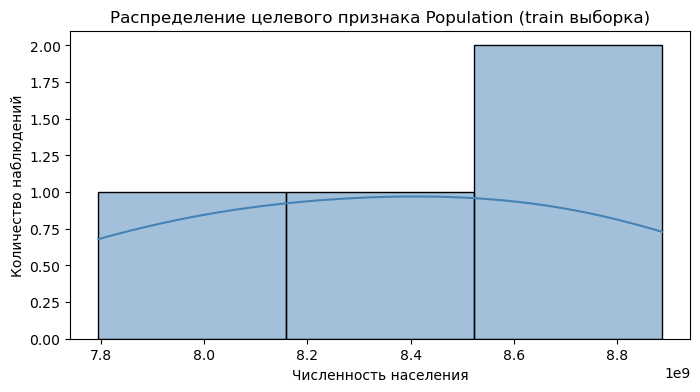

count    4.000000e+00
mean     8.353812e+09
std      4.704363e+08
min      7.794799e+09
25%      8.087028e+09
50%      8.366462e+09
75%      8.633247e+09
max      8.887524e+09
Name: Population, dtype: float64


In [26]:
plt.figure(figsize=(8,4))
sns.histplot(y_train, kde=True, color='steelblue')
plt.title("Распределение целевого признака Population (train выборка)")
plt.xlabel("Численность населения")
plt.ylabel("Количество наблюдений")
plt.show()

# Проверим статистику
print(y_train.describe())


Опять же данные распределены неравномерно, значит выборка несбалансированна. Лучше будет использовать Oversampling.

### 3.12 Приращение данных

In [27]:
# Oversampling
X_aug = X_train.copy()
y_aug = y_train.copy()

# Добавляем шум ±0.3% от значения
noise = np.random.normal(0, 0.003, size=len(y_train))
y_augmented = y_train * (1 + noise)

# Объединяем оригинальные и аугментированные данные
X_balanced = pd.concat([X_train, X_aug], axis=0)
y_balanced = pd.concat([y_train, pd.Series(y_augmented)], axis=0)

print(f"Размер до аугментации: {len(y_train)}")
print(f"Размер после Oversampling: {len(y_balanced)}")

# Undersampling 
undersample_frac = 0.7
X_under = X_train.sample(frac=undersample_frac, random_state=42)
y_under = y_train.loc[X_under.index]

print(f"Размер после Undersampling: {len(y_under)}")


Размер до аугментации: 4
Размер после Oversampling: 8
Размер после Undersampling: 3


### Вывод
В этой работе я посмотрела три набора данных, по успеваемости студентов, цен акций Starbucks и прогноз численности населения.
Для некоторых датасетов сделала предварительную очистку, разбиение на обучающую, контрольную и тестовую выборки, а также оценила сбалансированность и приращение данных. Сделала аугментацию (oversampling, undersampling), тем самым увеличив полноту выборок.
